# DWD Weather Hourly Data

## Setup for EDA and time series 

In [12]:
# Importing required libraries
import requests
import pandas as pd
import csv
import numpy as np
from itertools import permutations
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
##
##
import glob
import json
import re
import os
##

## Plotting Functions

In [4]:
def simple_lineplot(df, y, x="MESS_DATUM"):
    fig, ax = plt.subplots()
    sns.lineplot(x=x, y=y, data=df, ax=ax)
    ax.set(title='target_hourly', ylabel=y)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


In [51]:
def average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID'):
    grouped_df = df \
        .groupby([x, time, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    except:
        sns.lineplot(x=time, y=y, data=grouped_df, hue=group, ax=ax, palette='Set1')
    ax.set(title='Average target_hourly', ylabel=y);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()
##
##
def average_lineplot_all(df, y, x='date',  group=settime):
    grouped_df = df \
        .groupby([x, group], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    try:
        sns.lineplot(x=settime, y=y, data=grouped_df, ax=ax, index=settime)
    except:
        sns.lineplot(x=settime, y=y, data=grouped_df, ax=ax)
    ax.set(title='Average target_hourly', ylabel=y);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()

##
##
def average_lineplot_no_group(df, y, x='MESS_DATUM', time='year'):
    grouped_df = df \
        .groupby([x, time], as_index=False)\
        .agg({y: np.mean}) \
        .set_index(x)

    fig, ax = plt.subplots()
    sns.lineplot(x=time, y=y, data=grouped_df, ax=ax)
    ax.set(title='Average target_hourly', ylabel=y);
    plt.xticks(rotation=45)
    plt.tight_layout()
    #fig.savefig("visualisations/.png",dpi=300)
    plt.show()

## Data overview

### Details hourly weather data from the following sources  

- weather-hourly/CS_cloud_type_historical
- weather-hourly/CS_cloud_type_recent

- weather-hourly/FF_wind_historical
- weather-hourly/FF_wind_recent

- weather-hourly/FX_extreme_wind_historical
- weather-hourly/FX_extreme_wind_recent

- weather-hourly/F_wind_synopsis_historical
- weather-hourly/F_wind_synopsis_recent

- weather-hourly/N_cloudiness_historical
- weather-hourly/N_cloudiness_recent

- weather-hourly/RR_precipitation_historical
- weather-hourly/RR_precipitation_recent

- weather-hourly/SD_sun_hourly_historical
- weather-hourly/SD_sun_hourly_recent

- weather-hourly/ST_solar_hourly

- weather-hourly/VV_visibility_historical
- weather-hourly/VV_visibility_recent

- weather-hourly/WW_weather_phenomena_historical
- weather-hourly/WW_weather_phenomena_recent



### Paths to 'weather-hourly' data folder

In [9]:
path_CS_cloud_type_historical_  = '../data/weather-hourly/CS_cloud_type_historical/*.txt'
path_CS_cloud_type_recent_  = '../data/weather-hourly/CS_cloud_type_recent/*.txt'


path_FF_wind_historical_  = '../data/weather-hourly/FF_wind_historical/*.txt'
path_FF_wind_recent_   = '../data/weather-hourly/FF_wind_recent/*.txt' 
path_FX_extreme_wind_historical_ = '../data/weather-hourly/FX_extreme_wind_historical/*.txt'
path_FX_extreme_wind_recent_  = '../data/weather-hourly/FX_extreme_wind_recent/*.txt'
path_F_wind_synopsis_historical_  = '../data/weather-hourly/F_wind_synopsis_historical/*.txt'
path_F_wind_synopsis_recent_  = '../data/weather-hourly/F_wind_synopsis_recent/*.txt'


path_N_cloudiness_historical_  = '../data/weather-hourly/N_cloudiness_historical/*.txt'
path_N_cloudiness_recent_  = '../data/weather-hourly/N_cloudiness_recent/*.txt'


path_RR_precipitation_historical_  = '../data/weather-hourly/RR_precipitation_historical/*.txt'
path_RR_precipitation_recent_  = '../data/weather-hourly/RR_precipitation_recent/*.txt'


path_SD_sun_hourly_historical_  = '../data/weather-hourly/SD_sun_hourly_historical/*.txt'
path_SD_sun_hourly_recent_  = '../data/weather-hourly/SD_sun_hourly_recent/*.txt'


path_ST_solar_hourly_  = '../data/weather-hourly/ST_solar_hourly/*.txt'


path_VV_visibility_historical_  = '../data/weather-hourly/VV_visibility_historical/*.txt'
path_VV_visibility_recent_  = '../data/weather-hourly/VV_visibility_recent/*.txt'


path_WW_weather_phenomena_historical_  = '../data/weather-hourly/WW_weather_phenomena_historical/*.txt'
path_WW_weather_phenomena_recent_  = '../data/weather-hourly/WW_weather_phenomena_recent/*.txt'

### Columns descriptions  of weather-hourly/CS_cloud_
|column name               | Description             | uom           | Type        | format   |
|---------------------| ---------------------|-----------------------------------------|---------------------|--------------------- |
|STATIONS_ID| Station ID|          |            |VARCHAR2|     
|MESS_DATUM| reference date ||| NUMBER|YYYYMMDD |
|QN_8              |quality level of the following columns             | numerical code       | NUMBER        | 990  |
|V_N             |[\total cloud cover\,\missing value = -999\]             |1/8       |NUMBER        |9990  |
|V_N_I            |[\index how measurement is taken\, \P = by human person\,\I = by instrument\,\missing value = -999\]|    
VARCHAR2        |  |
|V_S1_CS            |[\cloud type of 1. layer\,\missing value = -999\]            |numerical code       |NUMBER        |9990  |
|V_S1_CSA            |[\abbrev. cloud type 1.layer\,\missing value = -999\]          |alpha-numerical code       |VARCHAR2       | |
|V_S1_HHS             |[\lower boundary height of 1.layer\, \missing value = -999\]            |m      |NUMBER        |99990  |
|V_S1_NS             |[\cloud cover of 1. laye\,\missing value = -999\]           |1/8      |VARCHAR2        |9990 |
|V_S2_CS            |[\cloud type of 2. layer\,\missing value = -999\] |numerical code     |NUMBER        |9990 |
|V_S2_CSA             |[\abbrev. cloud type 2.layer\,\missing value = -999\]          |alpha-numerical code      |VARCHAR2        | |
|V_S2_HHS            |[\lower boundary height of 2.layer\, \missing value = -999\]          |m      |NUMBER        |99990 |
|V_S2_NS           |[\cloud cover of 1. laye\,\missing value = -999\]         |1/8     |VARCHAR2        |9990 |
|V_S3_CS           |[\cloud type of 3. layer\,\missing value = -999\]   |numerical code    |NUMBER        |9990 |
|V_S3_CSA          |[\abbrev. cloud type 3.layer\,\missing value = -999\]   |alpha-numerical code    |VARCHAR2     | |
|V_S3_HHS          |[\lower boundary height of 3.layer\, \missing value = -999\]   |m    |NUMBER     |99990 |
|V_S3_NS         |[\cloud cover of 3. layer\,\missing value = -999\]   |1/8    |VARCHAR2     |9990 |
|V_S4_CS         |[\cloud type of 4. layer\,\missing value = -999\]  |numerical code   |NUMBER     |9990 |
|V_S4_CSA        |[\abbrev. cloud type 4.layer\,\missing value = -999\]|alpha-numerical code   |VARCHAR2     | |
|V_S4_HHS        |[\lower boundary height of 4.layer\, \missing value = -999\]|m   |NUMBER    |99990 |
|V_S4_NS        |[\cloud cover of 4. layer\,\missing value = -999\]|1/8   |NUMBER    |99990 |










- Parameter: cloud coverage, cloud height, DELETE: cloud coverage, kind of cloud

- Unit(s): eighth, metre, numerical code

- Statistical processing:  hourly value, time series

- Temporal coverage: 1949-01-01 -- ...

### Quality Information

- The QUALITAETS_NIVEAU (QN) shows the quality control procedure applied for a data report (of several parameters) for a certain reporting time.

- Data before and including 1980 can reach as best quality check level QN=5. Data after 1980 can reach QN=10 as best quality check level.
- QN = 1 : only formal control;
- QN = 2 : controlled with individually defined criteria;
- QN = 3 : automatic control and correction;
- QN = 5 : historic, subjective procedures;
- QN = 7 : second control done, before correction;
- QN = 8 : quality control outside ROUTINE;
- QN = 9 : not all parameters corrected;
- QN = 10 : quality control finished, all corrections finished.

- QB = 0 : denotes not flagged,
- QB = 1 : had no objections (either checked and not objected, or not checked and not objected, this can be interpreted only when considering QN);
- QB = 2 : corrected;
- QB = 3 : confirmed with objection rejected;
- QB = 4 : added or calculated;
- QB = 5 : objected;
- QB = 6 : only formally checked;
- QB = 7 : formal objection;
- QB = -999 : quality flag does not exist.

## 'CS_cloud_type_historical and CS_cloud_type_recent' - data import and preprocessing 

In [31]:
# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order 

txt_files =  sorted(glob.glob(path_CS_cloud_type_historical_), reverse=False)
txt_files.extend(sorted(glob.glob(path_CS_cloud_type_recent_), reverse=False))

# Create an empty list to store the data from each txt file
main_CScloud_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")
    print(file, df.shape)
    # Append the DataFrame to the list
    main_CScloud_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
KL_CScloud_df = pd.concat(main_CScloud_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#KL_CScloud_df.to_csv('../data/Weather_CScloud_hourly.csv')

/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_28035/3105962900.py:15: DtypeWarning: Columns (6,10,14,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_table(file, sep = ";")


../data/weather-hourly/CS_cloud_type_historical/produkt_cs_stunde_19490101_20221231_01975.txt (586277, 22)


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_28035/3105962900.py:15: DtypeWarning: Columns (6,10,14,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_table(file, sep = ";")


../data/weather-hourly/CS_cloud_type_historical/produkt_cs_stunde_19490101_20221231_02290.txt (442169, 22)


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_28035/3105962900.py:15: DtypeWarning: Columns (6,10,14,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_table(file, sep = ";")


...

../data/weather-hourly/CS_cloud_type_historical/produkt_cs_stunde_19770420_20221231_05779.txt (295102, 22)


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_28035/3105962900.py:15: DtypeWarning: Columns (6,10,14,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_table(file, sep = ";")


../data/weather-hourly/CS_cloud_type_historical/produkt_cs_stunde_19840807_20221231_04928.txt (221820, 22)


/var/folders/75/2hrhpj_x0q94k87nqmpdwckm0000gn/T/ipykernel_28035/3105962900.py:15: DtypeWarning: Columns (6,10,14,18) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_table(file, sep = ";")


../data/weather-hourly/CS_cloud_type_historical/produkt_cs_stunde_19970107_20221231_05856.txt (225646, 22)
../data/weather-hourly/CS_cloud_type_recent/produkt_cs_stunde_20220116_20230719_00183.txt (13006, 22)
../data/weather-hourly/CS_cloud_type_recent/produkt_cs_stunde_20220116_20230719_00662.txt (13147, 22)
../data/weather-hourly/CS_cloud_type_recent/produkt_cs_stunde_20220116_20230719_00853.txt (13200, 22)
../data/weather-hourly/CS_cloud_type_recent/produkt_cs_stunde_20220116_20230719_01048.txt (13200, 22)
../data/weather-hourly/CS_cloud_type_recent/produkt_cs_stunde_20220116_20230719_01358.txt (13138, 22)
../data/weather-hourly/CS_cloud_type_recent/produkt_cs_stunde_20220116_20230719_01684.txt (13178, 22)
../data/weather-hourly/CS_cloud_type_recent/produkt_cs_stunde_20220116_20230719_01975.txt (13199, 22)
../data/weather-hourly/CS_cloud_type_recent/produkt_cs_stunde_20220116_20230719_02290.txt (13194, 22)
../data/weather-hourly/CS_cloud_type_recent/produkt_cs_stunde_20220116_202307

In [32]:
KL_CScloud_df.columns, KL_CScloud_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_8', ' V_N', 'V_N_I', 'V_S1_CS',
        'V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
        'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS',
        'V_S4_CSA', 'V_S4_HHS', 'V_S4_NS', 'eor'],
       dtype='object'),
 (9258135, 22))

In [33]:
# replace leading spaces in column titles
#KL_CScloud_df.columns = KL_CScloud_df.columns.str.replace(" ", "")
#KL_CScloud_df.columns, KL_CScloud_df.shape

In [34]:
KL_CScloud_df.head()

,STATIONS_ID,MESS_DATUM,QN_8,V_N,V_N_I,V_S1_CS,V_S1_CSA,V_S1_HHS,V_S1_NS,V_S2_CS,...,V_S2_NS,V_S3_CS,V_S3_CSA,V_S3_HHS,V_S3_NS,V_S4_CS,V_S4_CSA,V_S4_HHS,V_S4_NS,eor
0,1975,1949010100,1,0,P,-999,-999,-999,-999,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,eor
1,1975,1949010101,1,8,P,6,SC-999,1050,8,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,eor
2,1975,1949010102,1,8,P,6,SC-999,1050,8,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,eor
3,1975,1949010103,1,0,P,-999,-999,-999,-999,-999,...,-999,-999,-999,-999,-999,-999,-999,-999,-999,eor
4,1975,1949010104,1,4,P,-999,-999,-999,-999,0,...,1,-999,-999,-999,-999,-999,-999,-999,-999,eor


In [35]:
KL_CScloud_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9258135 entries, 0 to 9258134
Data columns (total 22 columns):
 #   Column       Dtype 
---  ------       ----- 
 0   STATIONS_ID  int64 
 1   MESS_DATUM   int64 
 2   QN_8         int64 
 3    V_N         int64 
 4   V_N_I        object
 5   V_S1_CS      int64 
 6   V_S1_CSA     object
 7   V_S1_HHS     int64 
 8   V_S1_NS      int64 
 9   V_S2_CS      int64 
 10  V_S2_CSA     object
 11  V_S2_HHS     int64 
 12  V_S2_NS      int64 
 13  V_S3_CS      int64 
 14  V_S3_CSA     object
 15  V_S3_HHS     int64 
 16  V_S3_NS      int64 
 17  V_S4_CS      int64 
 18  V_S4_CSA     object
 19  V_S4_HHS     int64 
 20  V_S4_NS      int64 
 21  eor          object
dtypes: int64(16), object(6)
memory usage: 1.5+ GB


In [36]:
KL_CScloud_df.describe().T

,count,mean,std,min,25%,50%,75%,max
STATIONS_ID,9258135.0,3.291331e+03,1.798568e+03,1.830000e+02,1.684000e+03,3.631000e+03,4.642000e+03,5.906000e+03
MESS_DATUM,9258135.0,1.997739e+09,1.739775e+07,1.949010e+09,1.986092e+09,2.000013e+09,2.012053e+09,2.023072e+09
QN_8,9258135.0,-8.110937e+00,9.906437e+01,-9.990000e+02,1.000000e+00,1.000000e+00,3.000000e+00,3.000000e+00
V_N,9258135.0,-4.896553e+00,9.943033e+01,-9.990000e+02,2.000000e+00,7.000000e+00,8.000000e+00,8.000000e+00
V_S1_CS,9258135.0,-4.557263e+02,5.004782e+02,-9.990000e+02,-9.990000e+02,-1.000000e+00,6.000000e+00,9.000000e+00
V_S1_HHS,9258135.0,8.499689e+02,2.353879e+03,-9.990000e+02,-9.990000e+02,3.600000e+02,1.260000e+03,2.100000e+04
V_S1_NS,9258135.0,-3.465291e+02,4.783225e+02,-9.990000e+02,-9.990000e+02,2.000000e+00,5.000000e+00,8.000000e+00
V_S2_CS,9258135.0,-7.706303e+02,4.205463e+02,-9.990000e+02,-9.990000e+02,-9.990000e+02,-9.990000e+02,9.000000e+00
V_S2_HHS,9258135.0,1.987841e+02,2.399749e+03,-9.990000e+02,-9.990000e+02,-9.990000e+02,6.800000e+02,1.950000e+04
V_S2_NS,9258135.0,-7.036434e+02,4.577877e+02,-9.990000e+02,-9.990000e+02,-9.990000e+02,3.000000e+00,9.000000e+00


### Missing Values

In [37]:
# check for missing values
#KL_CScloud_df.isnull().sum()


In [38]:
#myDF.convert_objects(convert_numeric=True)
#for col in ['V_S1_CSA']: 
for col in ['V_S1_CS', 'V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS', 'V_S2_NS', 
            'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS', 'V_S4_CSA', 'V_S4_HHS', 'V_S4_NS', 'eor']:
    KL_CScloud_df[col] = KL_CScloud_df[col].apply(lambda x: int(x) if str(x).isdigit() else None)

In [39]:
#for col in ['V_S1_CS', 'V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS', 'V_S2_NS', 
 #           'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS', 'V_S4_CSA', 'V_S4_HHS', 'V_S4_NS', 'eor']:
 #      KL_CScloud_df[col] = KL_CScloud_df[col].replace('None', np.nan) # -999 is missing values
KL_CScloud_df.replace(to_replace=[None], value=np.nan, inplace=True)


In [40]:

#['V_S1_CSA']

In [41]:
#KL_CScloud_df_n  = KL_CScloud_df.applymap(lambda x: int(x) if type(x) == str and x.isdigit() else x)
KL_CScloud_df.head()

,STATIONS_ID,MESS_DATUM,QN_8,V_N,V_N_I,V_S1_CS,V_S1_CSA,V_S1_HHS,V_S1_NS,V_S2_CS,...,V_S2_NS,V_S3_CS,V_S3_CSA,V_S3_HHS,V_S3_NS,V_S4_CS,V_S4_CSA,V_S4_HHS,V_S4_NS,eor
0,1975,1949010100,1,0,P,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1975,1949010101,1,8,P,6.0,NaN,1050.0,8.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1975,1949010102,1,8,P,6.0,NaN,1050.0,8.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1975,1949010103,1,0,P,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1975,1949010104,1,4,P,NaN,NaN,NaN,NaN,0.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
# check for missing values again
KL_CScloud_df.isnull().sum()

STATIONS_ID          0
MESS_DATUM           0
QN_8                 0
 V_N                 0
V_N_I                0
V_S1_CS        4632403
V_S1_CSA       9258135
V_S1_HHS       3269540
V_S1_NS        3309567
V_S2_CS        7334075
V_S2_CSA       9258135
V_S2_HHS       6540009
V_S2_NS        6537949
V_S3_CS        8997091
V_S3_CSA       9258135
V_S3_HHS       8558574
V_S3_NS        8558315
V_S4_CS        9157435
V_S4_CSA       9258135
V_S4_HHS       9158376
V_S4_NS        9157436
eor            9258135
dtype: int64

### Day, year and month format 

In [44]:
# convert date into datetime format
KL_CScloud_df['MESS_DATUM'] = pd.to_datetime(KL_CScloud_df['MESS_DATUM'], format='%Y%m%d%H')# %Y%m%d%H%M%S

# Extract year, month and date from the datetime object
KL_CScloud_df['decade'] = KL_CScloud_df['MESS_DATUM'].dt.year//10*10
KL_CScloud_df['date'] = KL_CScloud_df['MESS_DATUM'].dt.date
KL_CScloud_df['year'] = KL_CScloud_df['MESS_DATUM'].dt.year
KL_CScloud_df['month'] = KL_CScloud_df['MESS_DATUM'].dt.month
KL_CScloud_df['week'] = KL_CScloud_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
KL_CScloud_df['day'] = KL_CScloud_df['MESS_DATUM'].dt.day
KL_CScloud_df['hour'] = KL_CScloud_df['MESS_DATUM'].dt.hour
#KL_CScloud_df['minute'] = KL_CScloud_df['MESS_DATUM'].dt.minute
KL_CScloud_df['dayofyear'] = KL_CScloud_df['MESS_DATUM'].dt.dayofyear
KL_CScloud_df.head()

,STATIONS_ID,MESS_DATUM,QN_8,V_N,V_N_I,V_S1_CS,V_S1_CSA,V_S1_HHS,V_S1_NS,V_S2_CS,...,eor,decade,date,year,month,week,day,hour,minute,dayofyear
0,1975,1949-01-01 00:00:00,1,0,P,NaN,NaN,NaN,NaN,NaN,...,NaN,1940,1949-01-01,1949,1,53,1,0,0,1
1,1975,1949-01-01 01:00:00,1,8,P,6.0,NaN,1050.0,8.0,NaN,...,NaN,1940,1949-01-01,1949,1,53,1,1,0,1
2,1975,1949-01-01 02:00:00,1,8,P,6.0,NaN,1050.0,8.0,NaN,...,NaN,1940,1949-01-01,1949,1,53,1,2,0,1
3,1975,1949-01-01 03:00:00,1,0,P,NaN,NaN,NaN,NaN,NaN,...,NaN,1940,1949-01-01,1949,1,53,1,3,0,1
4,1975,1949-01-01 04:00:00,1,4,P,NaN,NaN,NaN,NaN,0.0,...,NaN,1940,1949-01-01,1949,1,53,1,4,0,1


In [ ]:
 # convert date into datetime format
 #'STATIONS_ID', 'MESS_DATUM', 'QN_8', 'V_N_I', 'V_N'
#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
#target = ''

### Drop columns weather climate data

In [45]:
#'STATIONS_ID', 'MESS_DATUM', 'QN_8', ' V_N', 'V_N_I', 'V_S1_CS','V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
#'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS','V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'
KL_CScloud_df_dropcol = KL_CScloud_df.drop(['eor', 'month', 'day', 'week', 'dayofyear', 'decade', 'minute'], axis=1)
KL_CScloud_df_dropcol.head()
#KL_climate_df_dropcol.to_csv('../data/Weather_KL_climate_historical_daily.csv')

,STATIONS_ID,MESS_DATUM,QN_8,V_N,V_N_I,V_S1_CS,V_S1_CSA,V_S1_HHS,V_S1_NS,V_S2_CS,...,V_S3_CSA,V_S3_HHS,V_S3_NS,V_S4_CS,V_S4_CSA,V_S4_HHS,V_S4_NS,date,year,hour
0,1975,1949-01-01 00:00:00,1,0,P,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1949-01-01,1949,0
1,1975,1949-01-01 01:00:00,1,8,P,6.0,NaN,1050.0,8.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1949-01-01,1949,1
2,1975,1949-01-01 02:00:00,1,8,P,6.0,NaN,1050.0,8.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1949-01-01,1949,2
3,1975,1949-01-01 03:00:00,1,0,P,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1949-01-01,1949,3
4,1975,1949-01-01 04:00:00,1,4,P,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1949-01-01,1949,4


### Visualization

In [22]:
#'STATIONS_ID', 'MESS_DATUM', 'QN_8', ' V_N', 'V_N_I', 'V_S1_CS','V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
#'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS','V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'
#target = 'V_S1_CS'
#simple_lineplot(df=KL_CScloud_df_dropcol, y=target)

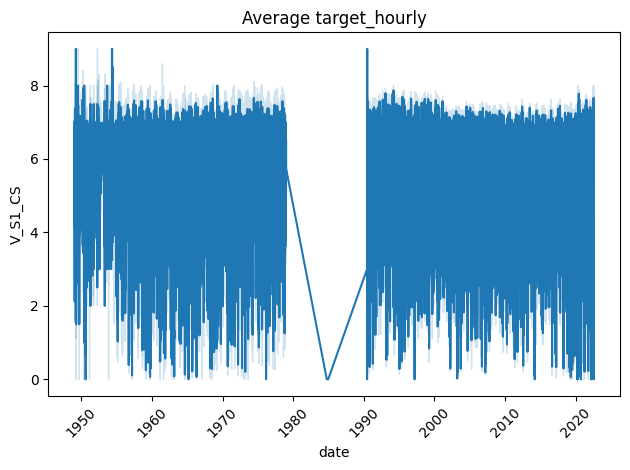

In [26]:
#'STATIONS_ID', 'MESS_DATUM', 'QN_8', ' V_N', 'V_N_I', 'V_S1_CS','V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
#'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS','V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'
target = 'V_S1_CS'#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='date')

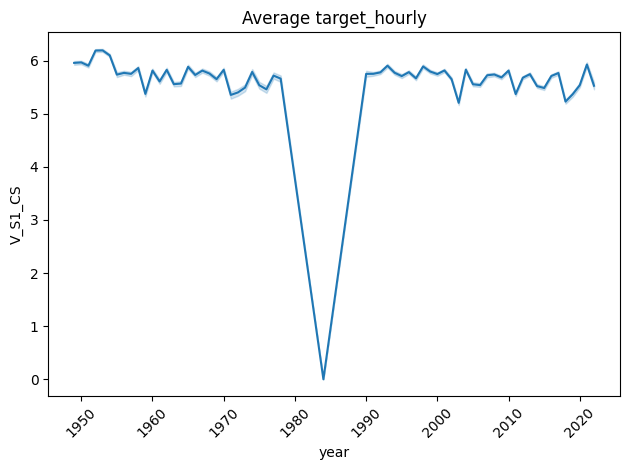

In [54]:
target = 'V_S1_CS'
average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='year')

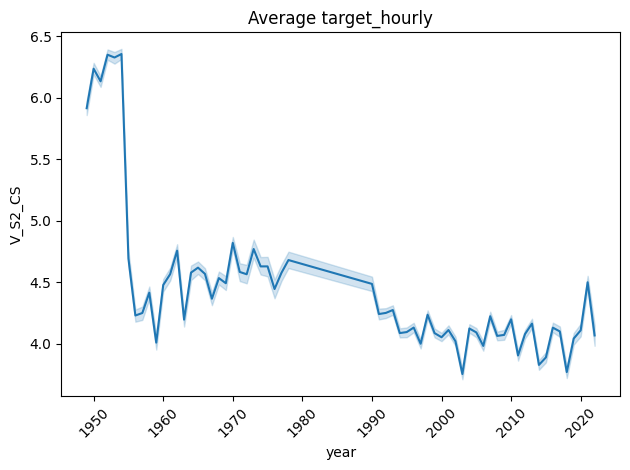

In [46]:
target = 'V_S2_CS'
average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='year')

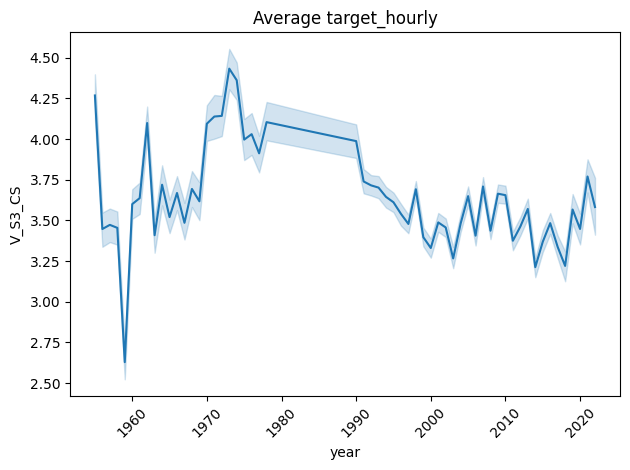

In [53]:
target = 'V_S3_CS'
average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='year')

In [56]:
#target = 'V_S1_CSA'
#average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='year')

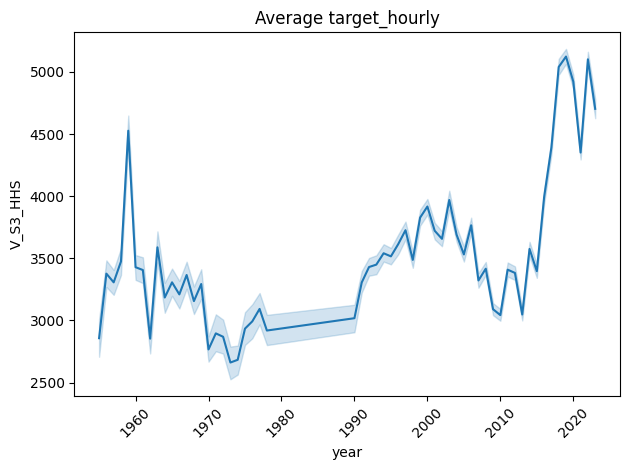

In [49]:
target = 'V_S3_HHS'
average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='year')

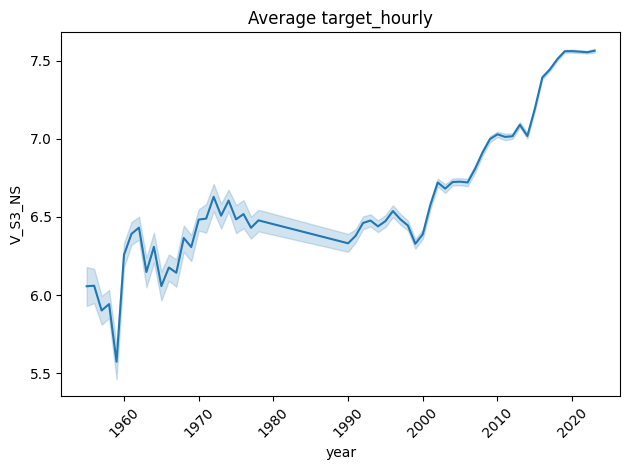

In [48]:
target = 'V_S3_NS'
average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='year')

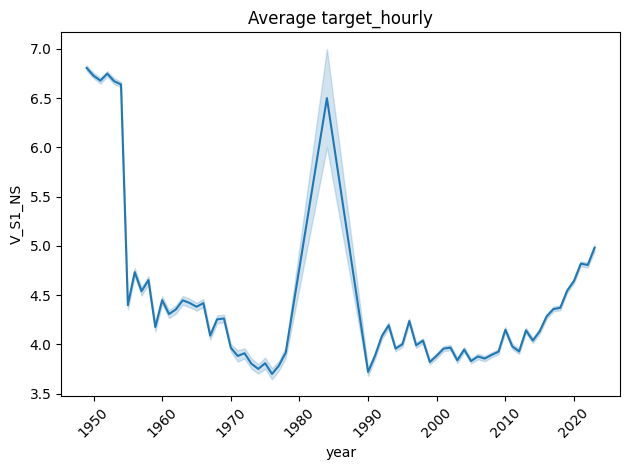

In [47]:
target = 'V_S1_NS'
average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='year')

In [ ]:
#'QN_8', ' V_N', 'V_N_I', 'V_S1_CS','V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
#'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS','V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'

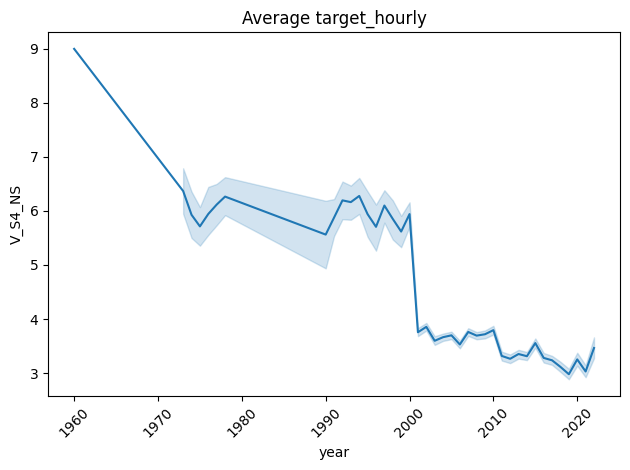

In [57]:
 #'QN_8', ' V_N', 'V_N_I', 'V_S1_CS','V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
#'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS','V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'
target = 'V_S4_NS'
average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='year')

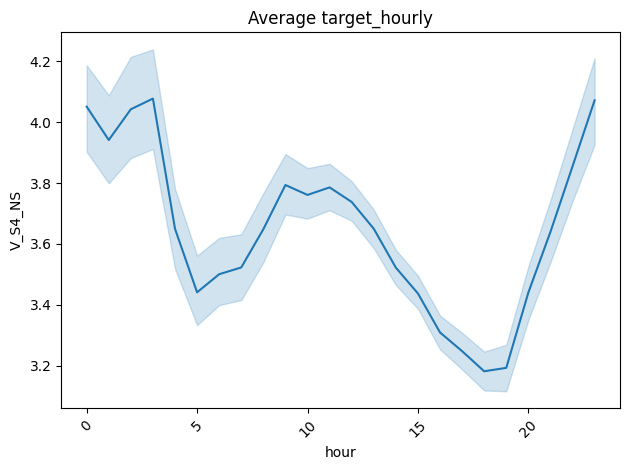

In [59]:
 #'QN_8', ' V_N', 'V_N_I', 'V_S1_CS','V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
#'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS','V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'
target = 'V_S4_NS'
average_lineplot_no_group(df=KL_CScloud_df_dropcol, y=target, x="MESS_DATUM", time='hour')

In [63]:
 #Aggregate 
Aggr_KL_CScloud_df = KL_CScloud_df \
    .groupby(['date', 'year', 'month', 'day', 'dayofyear',' decade', 'hour'], as_index=False)\
    .agg({target: np.mean}) \
    .set_index('date')

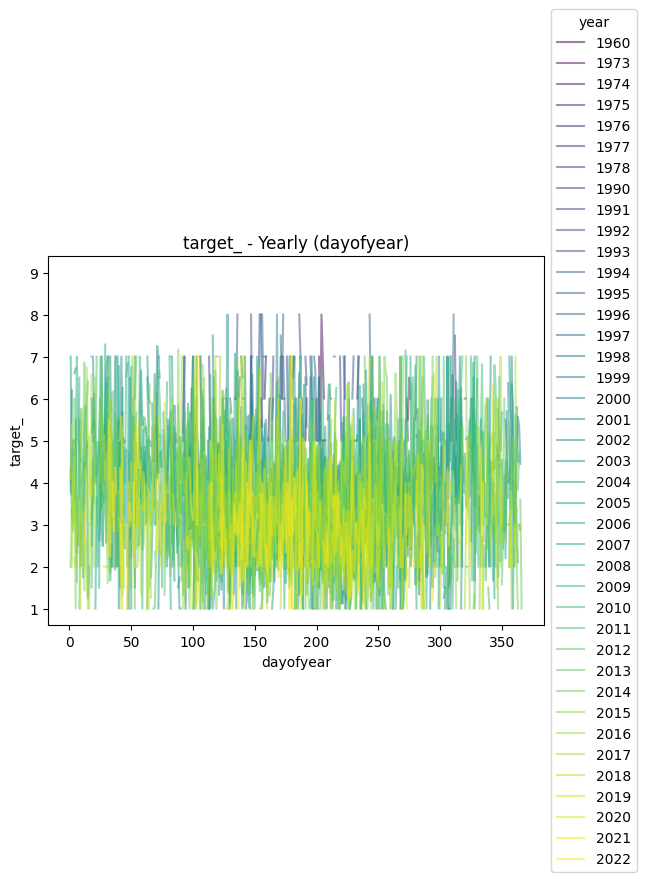

In [64]:
 #'QN_8', ' V_N', 'V_N_I', 'V_S1_CS','V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
#'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS','V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=Aggr_KL_CScloud_df[['year', 'dayofyear', target]], index='dayofyear', columns='year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title='target_ - Yearly (dayofyear)', ylabel='target_');

#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

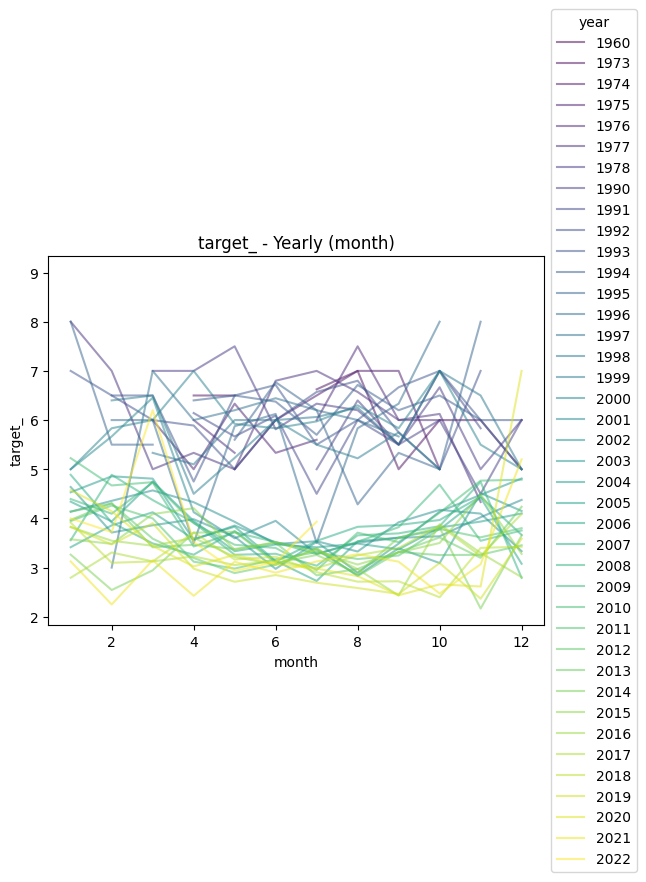

In [71]:
# 'QN_8', ' V_N', 'V_N_I', 'V_S1_CS','V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
#'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS','V_S4_CSA', 'V_S4_HHS', 'V_S4_NS' 
#'QN_8', ' V_N', 'V_N_I', 'V_S1_CS','V_S1_CSA', 'V_S1_HHS', 'V_S1_NS', 'V_S2_CS', 'V_S2_CSA', 'V_S2_HHS',
#'V_S2_NS', 'V_S3_CS', 'V_S3_CSA', 'V_S3_HHS', 'V_S3_NS', 'V_S4_CS','V_S4_CSA', 'V_S4_HHS', 'V_S4_NS'
# Plot yearly seasonality
fig, ax = plt.subplots() 

pd.pivot_table(data=Aggr_KL_CScloud_df[['year', 'month', target]], index='month', columns='year') \
    [target] \
    .plot(cmap='viridis', alpha=0.5, ax=ax)

ax.legend(title='year', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set(title='target_ - Yearly (month)', ylabel='target_');

#fig.savefig("visualisations/total_energy_generation_mwh.png",dpi=300)

### Columns descriptions  of weather-hourly/F_wind_
|column name               | Description             | uom           | Type        | format   |
|---------------------| ---------------------|-----------------------------------------|---------------------|--------------------- |
|STATIONS_ID| Station ID|          |            |VARCHAR2|     
|MESS_DATUM| reference date ||| CHAR|YYYYMMDDHH24|
|QN_8              |quality level            | numerical code       |NUMBER       |990  |
|FF            |[\windspeed\,\missing value = -999\]             |m/s      |NUMBER        |990.0 |
|DD            |[\winddirection\,\missing value= = -999\]             |°      |NUMBER        |990.0 |





- Parameter: wind velocity, wind direction

- Unit(s): m/s, degree

- Statistical processing: time series, hourly mean

- Temporal coverage: 1893-01-01 -- ...

### Quality Information

- The QUALITAETS_NIVEAU (QN) 
 shows the quality control procedure applied for a data report (of several parameters) for a certain reporting time.
 
Data before and including 1980 can reach as best quality check level QN=5. Data after 1980 can reach QN=10 as best quality check level.

- QN = 1 : only formal control;
- QN = 2 : controlled with individually defined criteria;
- QN = 3 : automatic control and correction;
- QN = 5 : historic, subjective procedures;
- QN = 7 : second control done, before correction;
- QN = 8 : quality control outside ROUTINE;
- QN = 9 : not all parameters corrected;
- QN = 10 : quality control finished, all corrections finished.


- The QUALITAETS_BYTE (QB) denotes whether the value was objected to and/or corrected.

- QB = 0 : denotes not flagged,
- QB = 1 : had no objections (either checked and not objected, or not checked and not objected, this can be interpreted only when considering QN);
- QB = 2 : corrected;
- QB = 3 : confirmed with objection rejected;
- QB = 4 : added or calculated;
- QB = 5 : objected;
- QB = 6 : only formally checked;
- QB = 7 : formal objection;
- QB = -999 : quality flag does not exist.

#### 'FF_wind_historical, FF_wind_recent, FX_extreme_wind_historical, FX_extreme_wind_recent, F_wind_synopsis_historical, F_wind_synopsis_recent, N_cloudiness_historical,N_cloudiness_recent ' - data import and preprocessing 

In [88]:

# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order 

txt_files =  sorted(glob.glob(path_FF_wind_historical_), reverse=False)
txt_files.extend(sorted(glob.glob(path_FF_wind_recent_), reverse=False))

txt_files.extend(sorted(glob.glob(path_FX_extreme_wind_historical_), reverse=False))
txt_files.extend(sorted(glob.glob(path_FX_extreme_wind_recent_), reverse=False))

txt_files.extend(sorted(glob.glob(path_F_wind_synopsis_historical_), reverse=False))
txt_files.extend(sorted(glob.glob(path_F_wind_synopsis_recent_), reverse=False))
# Create an empty list to store the data from each txt file
main_wind_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")
    print(file, df.shape)
    # Append the DataFrame to the list
    main_wind_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
wind_df = pd.concat(main_wind_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#RRprecipitation_df.to_csv('../data/Weather_wind_df_hourly.csv')



../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_18930101_20221231_03987.txt (1093957, 6)
../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_19370101_20221231_05100.txt (621130, 6)
../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_19390101_20221231_02290.txt (732826, 6)
../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_19500101_20221231_01975.txt (639631, 6)
../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_19510101_20221231_03015.txt (626764, 6)
../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_19540101_20221231_04271.txt (602254, 6)
../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_19550101_20221231_01358.txt (592324, 6)
../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_19560101_20221231_04336.txt (587217, 6)
../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_19580201_20221231_04466.txt (568352, 6)
../data/weather-hourly/FF_wind_historical/produkt_ff_stunde_19590701_20221231_02712.txt (556395, 6)

In [93]:
# replace leading spaces in column titles
wind_df.columns = wind_df.columns.str.replace(" ", "")
wind_df.columns, wind_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_3', 'F', 'D', 'eor', 'QN_8', 'FX_911',
        'FF', 'DD'],
       dtype='object'),
 (26553769, 10))

In [94]:
wind_df.head()

,STATIONS_ID,MESS_DATUM,QN_3,F,D,eor,QN_8,FX_911,FF,DD
0,3987,1893010100,5.0,5.4,-999.0,eor,NaN,NaN,NaN,NaN
1,3987,1893010101,5.0,5.5,-999.0,eor,NaN,NaN,NaN,NaN
2,3987,1893010102,5.0,5.2,-999.0,eor,NaN,NaN,NaN,NaN
3,3987,1893010103,5.0,5.2,-999.0,eor,NaN,NaN,NaN,NaN
4,3987,1893010104,5.0,5.3,-999.0,eor,NaN,NaN,NaN,NaN


In [95]:
 # convert date into datetime format
wind_df['MESS_DATUM'] = pd.to_datetime(wind_df['MESS_DATUM'], format='%Y%m%d%H')#'%Y%m%d')# %Y%m%d%H%M%S
# Extract year, month and date from the datetime object
wind_df['decade'] = wind_df['MESS_DATUM'].dt.year//10*10
wind_df['date'] = wind_df['MESS_DATUM'].dt.date
wind_df['year'] = wind_df['MESS_DATUM'].dt.year
wind_df['month'] = wind_df['MESS_DATUM'].dt.month
wind_df['week'] = wind_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
wind_df['day'] = wind_df['MESS_DATUM'].dt.day
wind_df['hour'] = wind_df['MESS_DATUM'].dt.hour
#wind_df['minute'] = ST_solar_df['MESS_DATUM'].dt.minute
wind_df['dayofyear'] = wind_df['MESS_DATUM'].dt.dayofyear
wind_df.head()


,STATIONS_ID,MESS_DATUM,QN_3,F,D,eor,QN_8,FX_911,FF,DD,decade,date,year,month,week,day,hour,dayofyear
0,3987,1893-01-01 00:00:00,5.0,5.4,-999.0,eor,NaN,NaN,NaN,NaN,1890,1893-01-01,1893,1,52,1,0,1
1,3987,1893-01-01 01:00:00,5.0,5.5,-999.0,eor,NaN,NaN,NaN,NaN,1890,1893-01-01,1893,1,52,1,1,1
2,3987,1893-01-01 02:00:00,5.0,5.2,-999.0,eor,NaN,NaN,NaN,NaN,1890,1893-01-01,1893,1,52,1,2,1
3,3987,1893-01-01 03:00:00,5.0,5.2,-999.0,eor,NaN,NaN,NaN,NaN,1890,1893-01-01,1893,1,52,1,3,1
4,3987,1893-01-01 04:00:00,5.0,5.3,-999.0,eor,NaN,NaN,NaN,NaN,1890,1893-01-01,1893,1,52,1,4,1


In [ ]:
 #'STATIONS_ID', 'MESS_DATUM', 'QN_3', 'F', 'D', 'eor', 'QN_8', 'FX_911',       'FF', 'DD', 'V_N_I', 'V_N'
#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
#target = ''

##### data import from N_cloudiness_historical and N_cloudiness_recent


### Columns descriptions  of weather-hourly/N_cloudiness_


|column name               | Description             | uom           | Type        | format   |
|---------------------| ---------------------|-----------------------------------------|---------------------|--------------------- |
|STATIONS_ID| Station ID|          |            |VARCHAR2|     
|MESS_DATUM|reference date|          |            |VARCHAR2|     


Parameter DELETE: cloud coverage

Unit(s) eighth

Statistical processing hourly value, time series

Temporal coverage 1949-01-01 -- .

Quality Information: The QUALITAETS_NIVEAU (QN) shows the quality control procedure applied for a data report (of several parameters) for a certain reporting time.

- Data before and including 1980 can reach as best quality check level QN=5. Data after 1980 can reach QN=10 as best quality check level.
- QN = 1 : only formal control;
- QN = 2 : controlled with individually defined criteria;
- QN = 3 : automatic control and correction;
- QN = 5 : historic, subjective procedures;
- QN = 7 : second control done, before correction;
- QN = 8 : quality control outside ROUTINE;
- QN = 9 : not all parameters corrected;
- QN = 10 : quality control finished, all corrections finished.
- The QUALITAETS_BYTE (QB) denotes whether the value was objected to and/or corrected.
- QB = 0 : denotes not flagged,
- QB = 1 : had no objections (either checked and not objected, or not checked and not objected, this can be interpreted only when considering QN);
- QB = 2 : corrected;
- QB = 3 : confirmed with objection rejected;
- QB = 4 : added or calculated;
- QB = 5 : objected;
- QB = 6 : only formally checked;
- QB = 7 : formal objection;
- QB = -999 : quality flag does not exist.



In [90]:
# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order 

txt_files =  sorted(glob.glob(path_N_cloudiness_historical_  ), reverse=False)
txt_files.extend(sorted(glob.glob(path_N_cloudiness_recent_ ), reverse=False))
# Create an empty list to store the data from each txt file
main_cloudiness_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")
    print(file, df.shape)
    # Append the DataFrame to the list
    main_cloudiness_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
cloudiness_df = pd.concat(main_cloudiness_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#cloudiness_df.to_csv('../data/cloudiness_df_hourly.csv')



../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_01975.txt (586251, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_02290.txt (442107, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_03631.txt (422025, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_04336.txt (547442, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_05100.txt (463911, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_05705.txt (457692, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_05906.txt (421721, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19501001_20221231_00662.txt (449648, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19510312_20221231_04466.txt (462988, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_

In [91]:
# replace leading spaces in column titles
cloudiness_df.columns = cloudiness_df.columns.str.replace(" ", "")
cloudiness_df.columns, cloudiness_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_8', 'V_N_I', 'V_N', 'eor'], dtype='object'),
 (9166524, 6))

In [92]:
 # convert date into datetime format
cloudiness_df['MESS_DATUM'] = pd.to_datetime(cloudiness_df['MESS_DATUM'], format='%Y%m%d%H')#'%Y%m%d')# %Y%m%d%H%M%S
# Extract year, month and date from the datetime object
cloudiness_df['decade'] = cloudiness_df['MESS_DATUM'].dt.year//10*10
cloudiness_df['date'] = cloudiness_df['MESS_DATUM'].dt.date
cloudiness_df['year'] = cloudiness_df['MESS_DATUM'].dt.year
cloudiness_df['month'] = cloudiness_df['MESS_DATUM'].dt.month
cloudiness_df['week'] = cloudiness_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
cloudiness_df['day'] = cloudiness_df['MESS_DATUM'].dt.day
cloudiness_df['hour'] = cloudiness_df['MESS_DATUM'].dt.hour
#cloudiness_df['minute'] = cloudiness_df['MESS_DATUM'].dt.minute
cloudiness_df['dayofyear'] = cloudiness_df['MESS_DATUM'].dt.dayofyear
cloudiness_df.head()


,STATIONS_ID,MESS_DATUM,QN_8,V_N_I,V_N,eor,decade,date,year,month,week,day,hour,dayofyear
0,1975,1949-01-01 00:00:00,1,P,0,eor,1940,1949-01-01,1949,1,53,1,0,1
1,1975,1949-01-01 01:00:00,1,P,8,eor,1940,1949-01-01,1949,1,53,1,1,1
2,1975,1949-01-01 02:00:00,1,P,8,eor,1940,1949-01-01,1949,1,53,1,2,1
3,1975,1949-01-01 03:00:00,1,P,0,eor,1940,1949-01-01,1949,1,53,1,3,1
4,1975,1949-01-01 04:00:00,1,P,4,eor,1940,1949-01-01,1949,1,53,1,4,1


In [ ]:
 #'STATIONS_ID', 'MESS_DATUM', 'QN_8', 'V_N_I', 'V_N'
#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
#target = ''

#### 'path_RR_precipitation_historical and path_RR_precipitation_recent' - data import and preprocessing 

In [72]:
# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order 

txt_files =  sorted(glob.glob(path_RR_precipitation_historical_), reverse=False)
txt_files.extend(sorted(glob.glob(path_RR_precipitation_recent_ ), reverse=False))

# Create an empty list to store the data from each txt file
main_RRprecipitation_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")
    print(file, df.shape)
    # Append the DataFrame to the list
    main_RRprecipitation_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
precipitation_df = pd.concat(main_RRprecipitation_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#RRprecipitation_df.to_csv('../data/Weather_precipitation_df_hourly.csv')



../data/weather-hourly/RR_precipitation_historical/produkt_rr_stunde_19950901_20221231_00183.txt (237691, 7)
../data/weather-hourly/RR_precipitation_historical/produkt_rr_stunde_19950901_20221231_00853.txt (238147, 7)
../data/weather-hourly/RR_precipitation_historical/produkt_rr_stunde_19950901_20221231_01048.txt (239173, 7)
../data/weather-hourly/RR_precipitation_historical/produkt_rr_stunde_19950901_20221231_01358.txt (166068, 7)
../data/weather-hourly/RR_precipitation_historical/produkt_rr_stunde_19950901_20221231_01684.txt (238293, 7)
../data/weather-hourly/RR_precipitation_historical/produkt_rr_stunde_19950901_20221231_02290.txt (237920, 7)
../data/weather-hourly/RR_precipitation_historical/produkt_rr_stunde_19950901_20221231_02712.txt (239132, 7)
../data/weather-hourly/RR_precipitation_historical/produkt_rr_stunde_19950901_20221231_03015.txt (237767, 7)
../data/weather-hourly/RR_precipitation_historical/produkt_rr_stunde_19950901_20221231_03631.txt (238864, 7)
../data/weather-hou

In [73]:
# replace leading spaces in column titles
precipitation_df.columns = precipitation_df.columns.str.replace(" ", "")
precipitation_df.columns, precipitation_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_8', 'R1', 'RS_IND', 'WRTR', 'eor'], dtype='object'),
 (5306089, 7))

In [74]:
precipitation_df.head()

,STATIONS_ID,MESS_DATUM,QN_8,R1,RS_IND,WRTR,eor
0,183,1995090100,1,0.0,0,-999,eor
1,183,1995090101,1,0.0,0,-999,eor
2,183,1995090102,1,0.0,0,-999,eor
3,183,1995090103,1,0.0,0,-999,eor
4,183,1995090104,1,0.0,0,-999,eor


In [75]:
 # convert date into datetime format
precipitation_df['MESS_DATUM'] = pd.to_datetime(precipitation_df['MESS_DATUM'], format='%Y%m%d%H')#'%Y%m%d')# %Y%m%d%H%M%S
# Extract year, month and date from the datetime object
precipitation_df['decade'] = precipitation_df['MESS_DATUM'].dt.year//10*10
precipitation_df['date'] = precipitation_df['MESS_DATUM'].dt.date
precipitation_df['year'] = precipitation_df['MESS_DATUM'].dt.year
precipitation_df['month'] = precipitation_df['MESS_DATUM'].dt.month
precipitation_df['week'] = precipitation_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
precipitation_df['day'] = precipitation_df['MESS_DATUM'].dt.day
precipitation_df['hour'] = precipitation_df['MESS_DATUM'].dt.hour
#precipitation_df['minute'] = ST_solar_df['MESS_DATUM'].dt.minute
precipitation_df['dayofyear'] = precipitation_df['MESS_DATUM'].dt.dayofyear
precipitation_df.head()


,STATIONS_ID,MESS_DATUM,QN_8,R1,RS_IND,WRTR,eor,decade,date,year,month,week,day,hour,dayofyear
0,183,1995-09-01 00:00:00,1,0.0,0,-999,eor,1990,1995-09-01,1995,9,35,1,0,244
1,183,1995-09-01 01:00:00,1,0.0,0,-999,eor,1990,1995-09-01,1995,9,35,1,1,244
2,183,1995-09-01 02:00:00,1,0.0,0,-999,eor,1990,1995-09-01,1995,9,35,1,2,244
3,183,1995-09-01 03:00:00,1,0.0,0,-999,eor,1990,1995-09-01,1995,9,35,1,3,244
4,183,1995-09-01 04:00:00,1,0.0,0,-999,eor,1990,1995-09-01,1995,9,35,1,4,244


In [ ]:
 #'STATIONS_ID', 'MESS_DATUM', 'QN_8', 'R1', 'RS_IND', 'WRTR'
#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
#target = ''

#### 'N_cloudiness_historical and N_cloudiness_recent' - data import and preprocessing 

In [67]:
# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order 

txt_files =  sorted(glob.glob(path_N_cloudiness_historical_), reverse=False)
txt_files.extend(sorted(glob.glob(path_N_cloudiness_recent_), reverse=False))

# Create an empty list to store the data from each txt file
main_cloudiness_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")#, encoding = "ISO-8859-1")
    print(file, df.shape)
    # Append the DataFrame to the list
    main_cloudiness_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
cloudiness_df = pd.concat(main_cloudiness_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#cloudiness_df.to_csv('../data/cloudiness_df_hourly.csv')


../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_01975.txt (586251, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_02290.txt (442107, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_03631.txt (422025, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_04336.txt (547442, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_05100.txt (463911, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_05705.txt (457692, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19490101_20221231_05906.txt (421721, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19501001_20221231_00662.txt (449648, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_19510312_20221231_04466.txt (462988, 6)
../data/weather-hourly/N_cloudiness_historical/produkt_n_stunde_

In [68]:
# replace leading spaces in column titles
cloudiness_df.columns = cloudiness_df.columns.str.replace(" ", "")
cloudiness_df.columns, cloudiness_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_8', 'V_N_I', 'V_N', 'eor'], dtype='object'),
 (9166524, 6))

In [70]:
cloudiness_df.head()

,STATIONS_ID,MESS_DATUM,QN_8,V_N_I,V_N,eor
0,1975,1949010100,1,P,0,eor
1,1975,1949010101,1,P,8,eor
2,1975,1949010102,1,P,8,eor
3,1975,1949010103,1,P,0,eor
4,1975,1949010104,1,P,4,eor


In [71]:
 # convert date into datetime format
cloudiness_df['MESS_DATUM'] = pd.to_datetime(cloudiness_df['MESS_DATUM'], format='%Y%m%d%H')#'%Y%m%d')# %Y%m%d%H%M%S
# Extract year, month and date from the datetime object
cloudiness_df['decade'] = cloudiness_df['MESS_DATUM'].dt.year//10*10
cloudiness_df['date'] = cloudiness_df['MESS_DATUM'].dt.date
cloudiness_df['year'] = cloudiness_df['MESS_DATUM'].dt.year
cloudiness_df['month'] = cloudiness_df['MESS_DATUM'].dt.month
cloudiness_df['week'] = cloudiness_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
cloudiness_df['day'] = cloudiness_df['MESS_DATUM'].dt.day
cloudiness_df['hour'] = cloudiness_df['MESS_DATUM'].dt.hour
#cloudiness_df['minute'] = ST_solar_df['MESS_DATUM'].dt.minute
cloudiness_df['dayofyear'] = cloudiness_df['MESS_DATUM'].dt.dayofyear
cloudiness_df.head()



,STATIONS_ID,MESS_DATUM,QN_8,V_N_I,V_N,eor,decade,date,year,month,week,day,hour,dayofyear
0,1975,1949-01-01 00:00:00,1,P,0,eor,1940,1949-01-01,1949,1,53,1,0,1
1,1975,1949-01-01 01:00:00,1,P,8,eor,1940,1949-01-01,1949,1,53,1,1,1
2,1975,1949-01-01 02:00:00,1,P,8,eor,1940,1949-01-01,1949,1,53,1,2,1
3,1975,1949-01-01 03:00:00,1,P,0,eor,1940,1949-01-01,1949,1,53,1,3,1
4,1975,1949-01-01 04:00:00,1,P,4,eor,1940,1949-01-01,1949,1,53,1,4,1


In [ ]:
 #'STATIONS_ID', 'MESS_DATUM', 'QN_8', 'V_N_I', 'V_N'
#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
#target = ''

#### 'SD_sun_hourly_historical and D_sun_hourly_recent' - data import and preprocessing 

In [61]:

# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order 

txt_files =  sorted(glob.glob(path_SD_sun_hourly_historical_), reverse=False)
txt_files.extend(sorted(glob.glob(path_SD_sun_hourly_recent_), reverse=False))

# Create an empty list to store the data from each txt file
main_sun_hourly_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")#, encoding = "ISO-8859-1")
    print(file, df.shape)
    # Append the DataFrame to the list
    main_sun_hourly_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
sun_hourly_df = pd.concat(main_sun_hourly_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#sun_hourly_df.to_csv('../data/sun_hourly.csv')


../data/weather-hourly/SD_sun_hourly_historical/produkt_sd_stunde_18930101_20221231_03987.txt (852512, 5)
../data/weather-hourly/SD_sun_hourly_historical/produkt_sd_stunde_19490101_20221231_01975.txt (485494, 5)
../data/weather-hourly/SD_sun_hourly_historical/produkt_sd_stunde_19510101_20221231_00183.txt (472103, 5)
../data/weather-hourly/SD_sun_hourly_historical/produkt_sd_stunde_19510101_20221231_00662.txt (471893, 5)
../data/weather-hourly/SD_sun_hourly_historical/produkt_sd_stunde_19510101_20221231_00853.txt (465807, 5)
../data/weather-hourly/SD_sun_hourly_historical/produkt_sd_stunde_19510101_20221231_01358.txt (465172, 5)
../data/weather-hourly/SD_sun_hourly_historical/produkt_sd_stunde_19510101_20221231_01684.txt (379527, 5)
../data/weather-hourly/SD_sun_hourly_historical/produkt_sd_stunde_19510101_20221231_02290.txt (472325, 5)
../data/weather-hourly/SD_sun_hourly_historical/produkt_sd_stunde_19510101_20221231_03015.txt (470656, 5)
../data/weather-hourly/SD_sun_hourly_historica

In [62]:
# replace leading spaces in column titles
sun_hourly_df.columns = sun_hourly_df.columns.str.replace(" ", "")
sun_hourly_df.columns, sun_hourly_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_7', 'SD_SO', 'eor'], dtype='object'),
 (10133184, 5))

In [64]:
sun_hourly_df.head()

,STATIONS_ID,MESS_DATUM,QN_7,SD_SO,eor
0,3987,1893010103,5,0.0,eor
1,3987,1893010104,5,0.0,eor
2,3987,1893010105,5,0.0,eor
3,3987,1893010106,5,0.0,eor
4,3987,1893010107,5,0.0,eor


In [66]:
 # convert date into datetime format
sun_hourly_df['MESS_DATUM'] = pd.to_datetime(sun_hourly_df['MESS_DATUM'], format='%Y%m%d%H')#'%Y%m%d')# %Y%m%d%H%M%S
# Extract year, month and date from the datetime object
sun_hourly_df['decade'] = sun_hourly_df['MESS_DATUM'].dt.year//10*10
sun_hourly_df['date'] = sun_hourly_df['MESS_DATUM'].dt.date
sun_hourly_df['year'] = sun_hourly_df['MESS_DATUM'].dt.year
sun_hourly_df['month'] = sun_hourly_df['MESS_DATUM'].dt.month
sun_hourly_df['week'] = sun_hourly_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
sun_hourly_df['day'] = sun_hourly_df['MESS_DATUM'].dt.day
sun_hourly_df['hour'] = sun_hourly_df['MESS_DATUM'].dt.hour
#ST_solar_df['minute'] = ST_solar_df['MESS_DATUM'].dt.minute
sun_hourly_df['dayofyear'] = sun_hourly_df['MESS_DATUM'].dt.dayofyear
sun_hourly_df.head()


,STATIONS_ID,MESS_DATUM,QN_7,SD_SO,eor,decade,date,year,month,week,day,hour,dayofyear
0,3987,1893-01-01 03:00:00,5,0.0,eor,1890,1893-01-01,1893,1,52,1,3,1
1,3987,1893-01-01 04:00:00,5,0.0,eor,1890,1893-01-01,1893,1,52,1,4,1
2,3987,1893-01-01 05:00:00,5,0.0,eor,1890,1893-01-01,1893,1,52,1,5,1
3,3987,1893-01-01 06:00:00,5,0.0,eor,1890,1893-01-01,1893,1,52,1,6,1
4,3987,1893-01-01 07:00:00,5,0.0,eor,1890,1893-01-01,1893,1,52,1,7,1


In [ ]:
#''STATIONS_ID', 'MESS_DATUM', 'QN_7', 'SD_SO'
#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
#target = ''

#### 'ST_solar_hourly' - data import and preprocessing   ST_solar_hourly

In [13]:
txt_files =  sorted(glob.glob(path_ST_solar_hourly_), reverse=False)

# Create an empty list to store the data from each txt file
main_ST_solar_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")#, encoding = "ISO-8859-1")
    print(file, df.shape)
    # Append the DataFrame to the list
    main_ST_solar_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
ST_solar_df = pd.concat(main_ST_solar_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#ST_solar_df.to_csv('../data/ST_solar_df_hourly.csv')



../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19451231_20230630_03987.txt (679342, 10)
../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19530101_20230630_02290.txt (617952, 10)
../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19570101_20230630_05705.txt (582888, 10)
../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19580101_20230630_00662.txt (574103, 10)
../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19580101_20230630_01358.txt (565343, 10)
../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19580101_20230630_05100.txt (569736, 10)
../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19610101_20230630_05404.txt (511799, 10)
../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19640101_20230630_03631.txt (521544, 10)
../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19770101_20230630_02712.txt (407568, 10)
../data/weather-hourly/ST_solar_hourly/produkt_st_stunde_19790101_20230630_04928.txt (390048, 10)
../data/weather-hour

In [14]:
# replace leading spaces in column titles
ST_solar_df.columns = ST_solar_df.columns.str.replace(" ", "")
ST_solar_df.columns, ST_solar_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',
        'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 'eor'],
       dtype='object'),
 (9201784, 10))

In [15]:
ST_solar_df.head()

,STATIONS_ID,MESS_DATUM,QN_592,ATMO_LBERG,FD_LBERG,FG_LBERG,SD_LBERG,ZENIT,MESS_DATUM_WOZ,eor
0,3987,1945123101:10,1,-999.0,0.0,0.0,0,146.08,1945123102:00,eor
1,3987,1945123102:10,1,-999.0,0.0,0.0,0,139.16,1945123103:00,eor
2,3987,1945123103:10,1,-999.0,0.0,0.0,0,130.76,1945123104:00,eor
3,3987,1945123104:10,1,-999.0,0.0,0.0,0,121.73,1945123105:00,eor
4,3987,1945123105:10,1,-999.0,0.0,0.0,0,112.61,1945123106:00,eor


In [16]:
 # convert date into datetime format
ST_solar_df['MESS_DATUM'] = pd.to_datetime(ST_solar_df['MESS_DATUM'], format='%Y%m%d%H:%M')#'%Y%m%d')# %Y%m%d%H%M%S
# Extract year, month and date from the datetime object
ST_solar_df['decade'] = ST_solar_df['MESS_DATUM'].dt.year//10*10
ST_solar_df['date'] =ST_solar_df['MESS_DATUM'].dt.date
ST_solar_df['year'] = ST_solar_df['MESS_DATUM'].dt.year
ST_solar_df['month'] = ST_solar_df['MESS_DATUM'].dt.month
ST_solar_df['week'] = ST_solar_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
ST_solar_df['day'] = ST_solar_df['MESS_DATUM'].dt.day
ST_solar_df['hour'] = ST_solar_df['MESS_DATUM'].dt.hour
#ST_solar_df['minute'] = ST_solar_df['MESS_DATUM'].dt.minute
ST_solar_df['dayofyear'] = ST_solar_df['MESS_DATUM'].dt.dayofyear
ST_solar_df.head()




,STATIONS_ID,MESS_DATUM,QN_592,ATMO_LBERG,FD_LBERG,FG_LBERG,SD_LBERG,ZENIT,MESS_DATUM_WOZ,eor,decade,date,year,month,week,day,hour,dayofyear
0,3987,1945-12-31 01:10:00,1,-999.0,0.0,0.0,0,146.08,1945123102:00,eor,1940,1945-12-31,1945,12,1,31,1,365
1,3987,1945-12-31 02:10:00,1,-999.0,0.0,0.0,0,139.16,1945123103:00,eor,1940,1945-12-31,1945,12,1,31,2,365
2,3987,1945-12-31 03:10:00,1,-999.0,0.0,0.0,0,130.76,1945123104:00,eor,1940,1945-12-31,1945,12,1,31,3,365
3,3987,1945-12-31 04:10:00,1,-999.0,0.0,0.0,0,121.73,1945123105:00,eor,1940,1945-12-31,1945,12,1,31,4,365
4,3987,1945-12-31 05:10:00,1,-999.0,0.0,0.0,0,112.61,1945123106:00,eor,1940,1945-12-31,1945,12,1,31,5,365


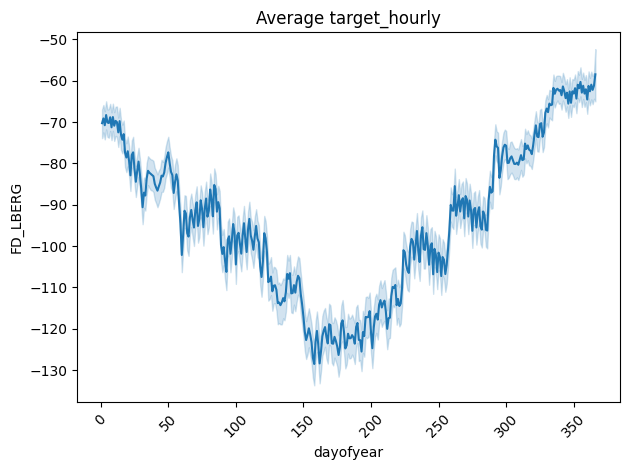

In [18]:

#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
target = 'FD_LBERG'
average_lineplot_no_group(df=ST_solar_df, y=target, x="MESS_DATUM", time='dayofyear')

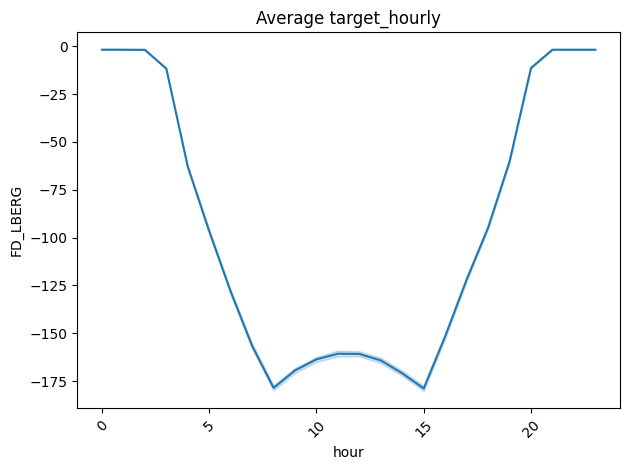

In [19]:
target = 'FD_LBERG'
average_lineplot_no_group(df=ST_solar_df, y=target, x="MESS_DATUM", time='hour')

In [54]:
#target = 'FD_LBERG'
#average_lineplot(df=ST_solar_df, y=target, x='MESS_DATUM', time='year', group='STATIONS_ID')


In [53]:
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#target = 'FD_LBERG'
#average_lineplot_all(df=ST_solar_df, y=target, x='date', group=settime)


#### 'visibility_historical and visibility_recent' - data import and preprocessing 

In [82]:
# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order 

txt_files =  sorted(glob.glob(path_VV_visibility_historical_), reverse=False)
txt_files.extend(sorted(glob.glob(path_VV_visibility_recent_), reverse=False))

# Create an empty list to store the data from each txt file
main_visibility_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";")#, encoding = "ISO-8859-1")
    print(file, df.shape)
    # Append the DataFrame to the list
    main_visibility_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
visibility_df = pd.concat(main_visibility_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#visibility_df.to_csv('../data/visibilitya_df_hourly.csv')



../data/weather-hourly/VV_visibility_historical/produkt_vv_stunde_19490101_20221231_01975.txt (585542, 6)
../data/weather-hourly/VV_visibility_historical/produkt_vv_stunde_19490101_20221231_02290.txt (439899, 6)
../data/weather-hourly/VV_visibility_historical/produkt_vv_stunde_19490101_20221231_03631.txt (421559, 6)
../data/weather-hourly/VV_visibility_historical/produkt_vv_stunde_19490101_20221231_04336.txt (547104, 6)
../data/weather-hourly/VV_visibility_historical/produkt_vv_stunde_19490101_20221231_05100.txt (466194, 6)
../data/weather-hourly/VV_visibility_historical/produkt_vv_stunde_19490101_20221231_05705.txt (457406, 6)
../data/weather-hourly/VV_visibility_historical/produkt_vv_stunde_19490101_20221231_05906.txt (442073, 6)
../data/weather-hourly/VV_visibility_historical/produkt_vv_stunde_19501001_20221231_00662.txt (451482, 6)
../data/weather-hourly/VV_visibility_historical/produkt_vv_stunde_19510312_20221231_04466.txt (462872, 6)
../data/weather-hourly/VV_visibility_historica

In [83]:
# replace leading spaces in column titles
visibility_df.columns = visibility_df.columns.str.replace(" ", "")
visibility_df.columns, visibility_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_8', 'V_VV_I', 'V_VV', 'eor'], dtype='object'),
 (9293405, 6))

In [84]:
visibility_df.head()

,STATIONS_ID,MESS_DATUM,QN_8,V_VV_I,V_VV,eor
0,1975,1949010100,1,P,12800,eor
1,1975,1949010101,1,P,12800,eor
2,1975,1949010102,1,P,12800,eor
3,1975,1949010103,1,P,12800,eor
4,1975,1949010104,1,P,12800,eor


In [87]:
 # convert date into datetime format
visibility_df['MESS_DATUM'] = pd.to_datetime(visibility_df['MESS_DATUM'], format='%Y%m%d%H')#'%Y%m%d')# %Y%m%d%H%M%S
# Extract year, month and date from the datetime object
visibility_df['decade'] = visibility_df['MESS_DATUM'].dt.year//10*10
visibility_df['date'] = visibility_df['MESS_DATUM'].dt.date
visibility_df['year'] = visibility_df['MESS_DATUM'].dt.year
visibility_df['month'] = visibility_df['MESS_DATUM'].dt.month
visibility_df['week'] = visibility_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
visibility_df['day'] = visibility_df['MESS_DATUM'].dt.day
visibility_df['hour'] = visibility_df['MESS_DATUM'].dt.hour
#visibility_df['minute'] = visibility_df['MESS_DATUM'].dt.minute
visibility_df['dayofyear'] = visibility_df['MESS_DATUM'].dt.dayofyear
visibility_df.head()

,STATIONS_ID,MESS_DATUM,QN_8,V_VV_I,V_VV,eor,decade,date,year,month,week,day,hour,dayofyear
0,1975,1949-01-01 00:00:00,1,P,12800,eor,1940,1949-01-01,1949,1,53,1,0,1
1,1975,1949-01-01 01:00:00,1,P,12800,eor,1940,1949-01-01,1949,1,53,1,1,1
2,1975,1949-01-01 02:00:00,1,P,12800,eor,1940,1949-01-01,1949,1,53,1,2,1
3,1975,1949-01-01 03:00:00,1,P,12800,eor,1940,1949-01-01,1949,1,53,1,3,1
4,1975,1949-01-01 04:00:00,1,P,12800,eor,1940,1949-01-01,1949,1,53,1,4,1


In [ ]:
#STATIONS_ID', 'MESS_DATUM', 'QN_8', 'V_VV_I', 'V_VV'
#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
#target = ''

#### 'path_WW_weather_phenomena_historical and path_WW_weather_phenomena_recent' - data import and preprocessing 

In [55]:
# Get a list of all CSV files in a directory
# Sorted will append files in alphabetical order 

txt_files =  sorted(glob.glob(path_WW_weather_phenomena_historical_), reverse=False)
txt_files.extend(sorted(glob.glob(path_WW_weather_phenomena_recent_), reverse=False))

# Create an empty list to store the data from each txt file
main_phenomena_df = []
count = 0
count_rows = 0

# Iterate over each txt file
for file in txt_files:
    # Read the txt file and store it in a DataFrame
    df = pd.read_table(file, sep = ";", encoding = "ISO-8859-1")
    print(file, df.shape)
    # Append the DataFrame to the list
    main_phenomena_df.append(df)

    #count how many .txt files are appended
    count += 1
    count_rows += df.shape[0]

print(count)
print(count_rows) #to check if the headlines (row with column names) are added in each iteration of for loop

# Concatenate all the DataFrames into a single DataFrame
phenomena_df = pd.concat(main_phenomena_df, ignore_index=False).reset_index(drop=True) #KL_climate_his = pd.concat(main_df, axis=1)
#RRprecipitation_df.to_csv('../data/phenomena_df_hourly.csv')



../data/weather-hourly/WW_weather_phenomena_historical/produkt_ww_stunde_19490101_20221231_01975.txt (585521, 6)
../data/weather-hourly/WW_weather_phenomena_historical/produkt_ww_stunde_19490101_20221231_02290.txt (441578, 6)
../data/weather-hourly/WW_weather_phenomena_historical/produkt_ww_stunde_19490101_20221231_03631.txt (421335, 6)
../data/weather-hourly/WW_weather_phenomena_historical/produkt_ww_stunde_19490101_20221231_04336.txt (546612, 6)
../data/weather-hourly/WW_weather_phenomena_historical/produkt_ww_stunde_19490101_20221231_05100.txt (466260, 6)
../data/weather-hourly/WW_weather_phenomena_historical/produkt_ww_stunde_19490101_20221231_05705.txt (457258, 6)
../data/weather-hourly/WW_weather_phenomena_historical/produkt_ww_stunde_19490101_20221231_05906.txt (416440, 6)
../data/weather-hourly/WW_weather_phenomena_historical/produkt_ww_stunde_19501001_20221231_00662.txt (449210, 6)
../data/weather-hourly/WW_weather_phenomena_historical/produkt_ww_stunde_19510312_20221231_04466

In [56]:
# replace leading spaces in column titles
phenomena_df.columns = phenomena_df.columns.str.replace(" ", "")
phenomena_df.columns, phenomena_df.shape

(Index(['STATIONS_ID', 'MESS_DATUM', 'QN_8', 'WW', 'WW_Text', 'eor'], dtype='object'),
 (9114630, 6))

In [57]:
phenomena_df.head()

,STATIONS_ID,MESS_DATUM,QN_8,WW,WW_Text,eor
0,1975,1949010100,1,0,Änderung des Bewölkungszustandes (keine Meteor...,eor
1,1975,1949010101,1,3,Änderung des Bewölkungszustandes (keine Meteor...,eor
2,1975,1949010102,1,2,Änderung des Bewölkungszustandes (keine Meteor...,eor
3,1975,1949010103,1,1,Änderung des Bewölkungszustandes (keine Meteor...,eor
4,1975,1949010104,1,3,Änderung des Bewölkungszustandes (keine Meteor...,eor


In [60]:
 # convert date into datetime format
phenomena_df['MESS_DATUM'] = pd.to_datetime(phenomena_df['MESS_DATUM'], format='%Y%m%d%H')#'%Y%m%d')# %Y%m%d%H%M%S
# Extract year, month and date from the datetime object
phenomena_df['decade'] = phenomena_df['MESS_DATUM'].dt.year//10*10
phenomena_df['date'] = phenomena_df['MESS_DATUM'].dt.date
phenomena_df['year'] = phenomena_df['MESS_DATUM'].dt.year
phenomena_df['month'] = phenomena_df['MESS_DATUM'].dt.month
phenomena_df['week'] = phenomena_df['MESS_DATUM'].dt.isocalendar().week.astype('int32')
phenomena_df['day'] = phenomena_df['MESS_DATUM'].dt.day
phenomena_df['hour'] = phenomena_df['MESS_DATUM'].dt.hour
#ST_solar_df['minute'] = ST_solar_df['MESS_DATUM'].dt.minute
phenomena_df['dayofyear'] = phenomena_df['MESS_DATUM'].dt.dayofyear
phenomena_df.head()

,STATIONS_ID,MESS_DATUM,QN_8,WW,WW_Text,eor,decade,date,year,month,week,day,hour,dayofyear
0,1975,1949-01-01 00:00:00,1,0,Änderung des Bewölkungszustandes (keine Meteor...,eor,1940,1949-01-01,1949,1,53,1,0,1
1,1975,1949-01-01 01:00:00,1,3,Änderung des Bewölkungszustandes (keine Meteor...,eor,1940,1949-01-01,1949,1,53,1,1,1
2,1975,1949-01-01 02:00:00,1,2,Änderung des Bewölkungszustandes (keine Meteor...,eor,1940,1949-01-01,1949,1,53,1,2,1
3,1975,1949-01-01 03:00:00,1,1,Änderung des Bewölkungszustandes (keine Meteor...,eor,1940,1949-01-01,1949,1,53,1,3,1
4,1975,1949-01-01 04:00:00,1,3,Änderung des Bewölkungszustandes (keine Meteor...,eor,1940,1949-01-01,1949,1,53,1,4,1


In [ ]:
#'STATIONS_ID', 'MESS_DATUM', 'QN_8', 'WW', 'WW_Text'
#simple_lineplot(df, y, x="MESS_DATUM")
#settime = 'dayofyear'#'year', 'month', 'day', 'dayofyear', 'decade', 'hour'
#average_lineplot(df, y, x='MESS_DATUM', time='year', group='STATIONS_ID')
#average_lineplot_no_group(df, y, x='MESS_DATUM', time='year')
#average_lineplot_all(df, y, x='date',  group=settime):
#'STATIONS_ID', 'MESS_DATUM', 'QN_592', 'ATMO_LBERG', 'FD_LBERG',   'FG_LBERG', 'SD_LBERG', 'ZENIT', 'MESS_DATUM_WOZ', 
#target = ''